In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/shopify_stock.csv")

In [3]:
df.head()

,date,open,high,low,close,adj_close,volume
0,2015-05-21 00:00:00-04:00,2.800,2.874,2.411,2.568,2.568,123039000
1,2015-05-22 00:00:00-04:00,2.607,3.110,2.600,2.831,2.831,28412000
2,2015-05-26 00:00:00-04:00,2.980,3.034,2.908,2.965,2.965,8202000
3,2015-05-27 00:00:00-04:00,3.067,3.081,2.700,2.750,2.750,7976000
4,2015-05-28 00:00:00-04:00,2.755,2.774,2.648,2.745,2.745,4000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2469 entries, 0 to 2468
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       2469 non-null   object 
 1   open       2469 non-null   float64
 2   high       2469 non-null   float64
 3   low        2469 non-null   float64
 4   close      2469 non-null   float64
 5   adj_close  2469 non-null   float64
 6   volume     2469 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 135.2+ KB


In [5]:
df.describe()

,open,high,low,close,adj_close,volume
count,2469.000000,2469.000000,2469.000000,2469.000000,2469.000000,2.469000e+03
mean,48.464345,49.505495,47.347795,48.456613,48.456613,1.657049e+07
std,43.633916,44.470235,42.642546,43.573362,43.573362,1.436909e+07
min,1.939000,1.985000,1.848000,1.933000,1.933000,1.039000e+06
25%,10.479000,10.635000,10.275000,10.450000,10.450000,8.098000e+06
50%,35.640999,36.879002,34.655998,35.874001,35.874001,1.275860e+07
75%,76.080002,77.169998,74.589996,75.800003,75.800003,2.060200e+07
max,171.800003,176.291794,168.509506,169.059998,169.059998,2.089590e+08


In [6]:
df['date']=pd.to_datetime(df['date'],utc=True)

In [7]:
df["date"].dtype

datetime64[ns, UTC]

In [8]:
df=df.sort_values("date")

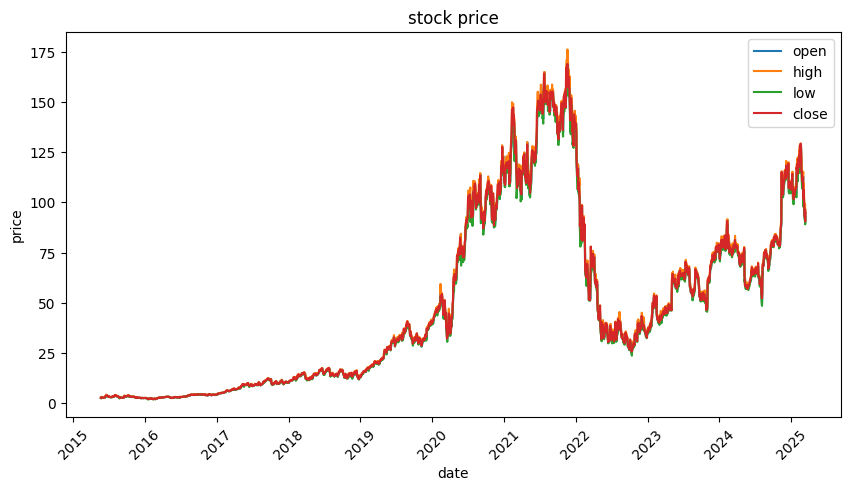

In [9]:
plt.figure(figsize=(10,5))
plt.plot(df.date,df["open"],label="open")
plt.plot(df.date,df["high"],label="high")
plt.plot(df.date,df["low"],label="low")
plt.plot(df.date,df["close"],label="close")

plt.title("stock price")

plt.xlabel("date")
plt.ylabel("price")
plt.xticks(rotation=45)
plt.legend()

(array([16071., 16436., 16801., 17167., 17532., 17897., 18262., 18628.,
        18993., 19358., 19723., 20089.]),
 [Text(16071.0, 0, '2014'),
  Text(16436.0, 0, '2015'),
  Text(16801.0, 0, '2016'),
  Text(17167.0, 0, '2017'),
  Text(17532.0, 0, '2018'),
  Text(17897.0, 0, '2019'),
  Text(18262.0, 0, '2020'),
  Text(18628.0, 0, '2021'),
  Text(18993.0, 0, '2022'),
  Text(19358.0, 0, '2023'),
  Text(19723.0, 0, '2024'),
  Text(20089.0, 0, '2025')])

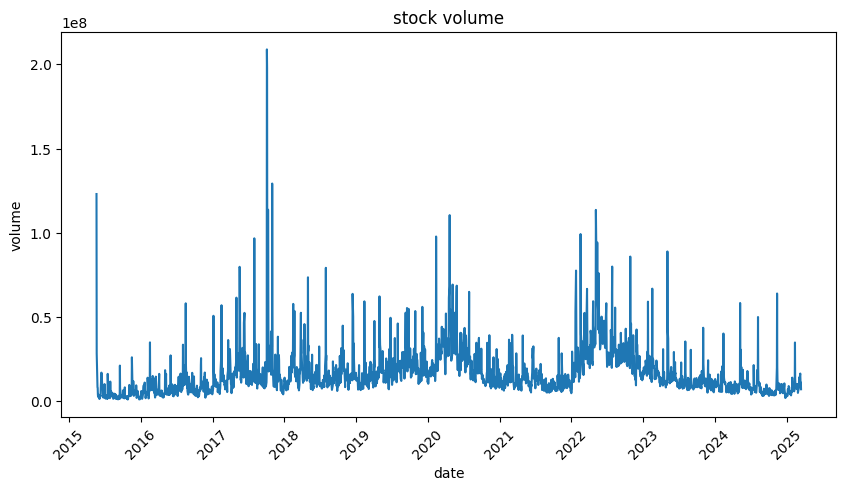

In [10]:
plt.figure(figsize=(10,5))
plt.plot(df["date"],df["volume"])

plt.title("stock volume")

plt.xlabel("date")
plt.ylabel("volume")
plt.xticks(rotation=45)

In [11]:
df["MA20"]=df["close"].rolling(20).mean()
df["MA50"]=df["close"].rolling(50).mean()
df["MA200"]=df["close"].rolling(200).mean()

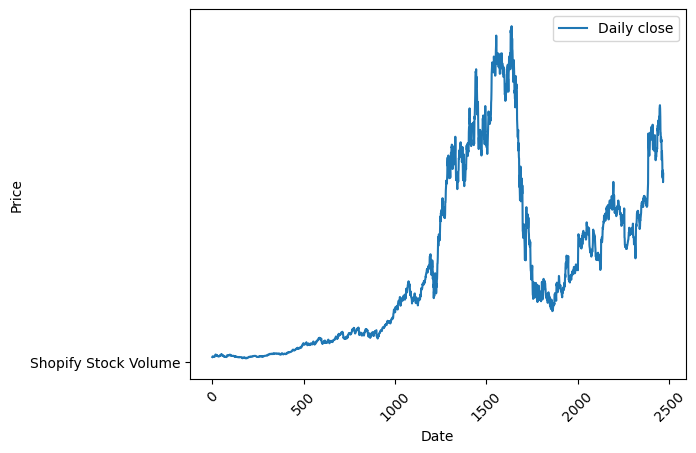

In [15]:
plt.plot(df.index, df["close"], label="Daily close")
plt.plot("Shopify Stock Volume")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [16]:
df["Daily_return"]=df["close"].pct_change()
df

,date,open,high,low,close,adj_close,volume,MA20,MA50,MA200,Daily_return
0,2015-05-21 04:00:00+00:00,2.800000,2.874000,2.411000,2.568000,2.568000,123039000,NaN,NaN,NaN,NaN
1,2015-05-22 04:00:00+00:00,2.607000,3.110000,2.600000,2.831000,2.831000,28412000,NaN,NaN,NaN,0.102414
2,2015-05-26 04:00:00+00:00,2.980000,3.034000,2.908000,2.965000,2.965000,8202000,NaN,NaN,NaN,0.047333
3,2015-05-27 04:00:00+00:00,3.067000,3.081000,2.700000,2.750000,2.750000,7976000,NaN,NaN,NaN,-0.072513
4,2015-05-28 04:00:00+00:00,2.755000,2.774000,2.648000,2.745000,2.745000,4000000,NaN,NaN,NaN,-0.001818
...,...,...,...,...,...,...,...,...,...,...,...
2464,2025-03-10 04:00:00+00:00,96.070000,96.186996,91.690002,92.750000,92.750000,16385300,114.415001,111.7678,86.86270,-0.073704
2465,2025-03-11 04:00:00+00:00,92.750000,95.109001,91.150002,92.949997,92.949997,12127100,113.067500,111.4232,87.04235,0.002156
2466,2025-03-12 04:00:00+00:00,96.669998,99.135002,95.290001,96.529999,96.529999,8531900,111.714500,111.1546,87.23150,0.038515
2467,2025-03-13 04:00:00+00:00,95.169998,95.529999,89.099998,90.589996,90.589996,11076400,110.219500,110.8028,87.39625,-0.061535


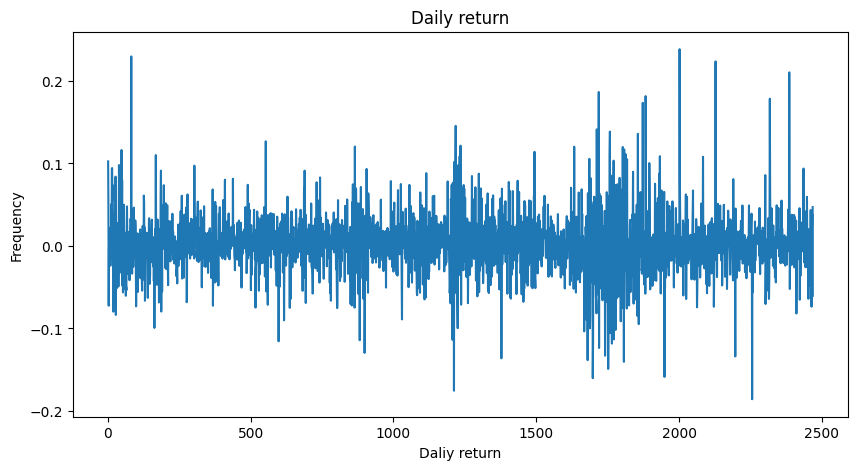

In [17]:
plt.figure(figsize=(10,5))
plt.plot(df["Daily_return"])

plt.title("Daily return")

plt.xlabel("Daliy return")
plt.ylabel("Frequency")
plt.show()


In [23]:
df["Rolling_Volatility_20"]=(df["Daily_return"].rolling(window=20).std())
df["Rolling_Volatility_20"].dropna()

,Rolling_Volatility_20
20,0.050832
21,0.047128
22,0.048007
23,0.043901
24,0.044948
...,...
2464,0.035907
2465,0.035251
2466,0.035785
2467,0.037396


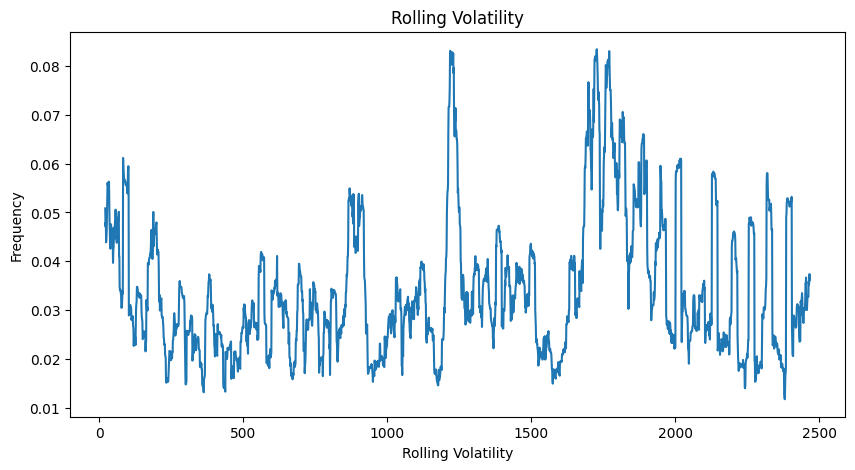

In [24]:
plt.figure(figsize=(10,5))
plt.plot(df["Rolling_Volatility_20"])

plt.title("Rolling Volatility")

plt.xlabel("Rolling Volatility")
plt.ylabel("Frequency")
plt.show()